# NSGA-II e NSGA-III no problema SCH1

Este notebook aplica as implementações próprias do repositório — [`modules/nsga2`](../../modules/nsga2/nsga2.py) e [`modules/nsga3`](../../modules/nsga3/nsga3.py) — ao problema de teste **SCH1** (Schaffer), que é o problema multiobjetivo contínuo mais simples com fronteira de Pareto conhecida analiticamente. Justamente por ter solução fechada, ele permite comparar a fronteira **teórica** com a fronteira **aproximada** pelos algoritmos e calcular as métricas de qualidade **GD**, **IGD** e **HV** sem precisar de um conjunto de referência estimado.

**Roteiro**

1. Definição do problema SCH1 e dedução da fronteira de Pareto teórica.
2. Configuração do experimento e operadores genéticos (SBX e mutação polinomial).
3. Execução do NSGA-II e do NSGA-III e comparação visual das fronteiras.
4. Definição e implementação das métricas GD, IGD e HV.
5. Evolução das métricas ao longo das gerações.
6. Robustez: repetição do experimento com várias sementes.
7. Efeito do número de pontos de referência no NSGA-III.
8. Conclusões.


In [23]:
import sys
import os

# Adiciona o diretório base ao sys.path
project_path = os.path.abspath(os.path.join(os.getcwd(), "../.."))  # Ajuste conforme a localização do notebook
if project_path not in sys.path:
    sys.path.insert(0, project_path)

import copy
import random
import time

import numpy as np
import matplotlib.pyplot as plt

from modules.nsga2 import nsga2_func
from modules.nsga3 import nsga3_func

# Paleta e estilo usados em todos os gráficos do notebook
C_TRUE = "#52514e"   # fronteira teórica (referência, tinta neutra)
C_N2 = "#2a78d6"     # NSGA-II
C_N3 = "#eb6834"     # NSGA-III

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.color": "#d9d9d6",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8f8e88",
    "axes.titlesize": 11,
    "axes.labelcolor": "#52514e",
    "lines.linewidth": 2.0,
    "legend.frameon": False,
})


## 1. O problema SCH1

O SCH1 (Schaffer, 1985) é um problema de **minimização** com uma única variável de decisão e dois objetivos:

$$
\text{minimizar} \quad
\begin{cases}
f_1(x) = x^2\\
f_2(x) = (x-2)^2
\end{cases}
\qquad x \in [-10, 10].
$$

> O intervalo clássico da literatura é $x\in[-10^3,10^3]$; aqui usamos $[-10,10]$, que preserva a estrutura do problema e evita que o esforço computacional seja dominado apenas pela busca grosseira da região de interesse.

### Fronteira de Pareto teórica

Os dois objetivos são parábolas com mínimos em $x=0$ e $x=2$, respectivamente:

* se $x < 0$, aumentar $x$ **reduz simultaneamente** $f_1$ e $f_2$ — logo todo $x<0$ é dominado por $x=0$;
* se $x > 2$, reduzir $x$ **reduz simultaneamente** os dois objetivos — logo todo $x>2$ é dominado por $x=2$;
* se $x \in [0,2]$, $f_1$ é crescente e $f_2$ é decrescente — melhorar um objetivo obriga a piorar o outro.

Portanto o **conjunto de Pareto** é $\mathcal{P}^{*}_{x} = [0,2]$ e a **fronteira de Pareto** no espaço de objetivos é a curva

$$
\mathcal{P}^{*} = \left\{ \left(f_1, \left(2-\sqrt{f_1}\right)^2\right) : f_1 \in [0,4] \right\},
$$

obtida substituindo $x=\sqrt{f_1}$ em $f_2$. Os pontos extremos são $(0,4)$ (ótimo de $f_1$) e $(4,0)$ (ótimo de $f_2$), e o **ponto nadir** é $(4,4)$.


In [24]:
def sch1(x: np.ndarray) -> np.ndarray:
    """
    Problema SCH1 (minimização): f1(x) = x^2 e f2(x) = (x - 2)^2.

    :param x: vetor de decisão de dimensão 1
    :return: vetor com os dois objetivos
    """
    x0 = float(x[0])
    return np.array([x0 ** 2, (x0 - 2.0) ** 2], dtype=float)


# As implementações do repositório recebem uma lista de funções escalares
def f1(x: np.ndarray) -> float:
    return float(x[0] ** 2)


def f2(x: np.ndarray) -> float:
    return float((x[0] - 2.0) ** 2)


OBJECTIVES = [f1, f2]


def true_pareto_front(num_points: int = 1000) -> np.ndarray:
    """
    Amostra uniformemente o conjunto de Pareto x* em [0, 2] e devolve os pontos
    correspondentes na fronteira de Pareto teórica.

    :param num_points: número de pontos amostrados
    :return: array (num_points x 2) com os objetivos (f1, f2)
    """
    x = np.linspace(0.0, 2.0, num_points)
    return np.column_stack([x ** 2, (x - 2.0) ** 2])


PF_TRUE = true_pareto_front(1000)

def fmt(point: np.ndarray) -> str:
    return "(" + ", ".join(f"{v:.3f}" for v in point) + ")"


print(f"pontos da fronteira teórica: {PF_TRUE.shape[0]}")
print(f"extremos: {fmt(PF_TRUE[0])} e {fmt(PF_TRUE[-1])}")
print(f"ponto nadir: {fmt(PF_TRUE.max(axis=0))}")


pontos da fronteira teórica: 1000
extremos: (0.000, 4.000) e (4.000, 0.000)
ponto nadir: (4.000, 4.000)


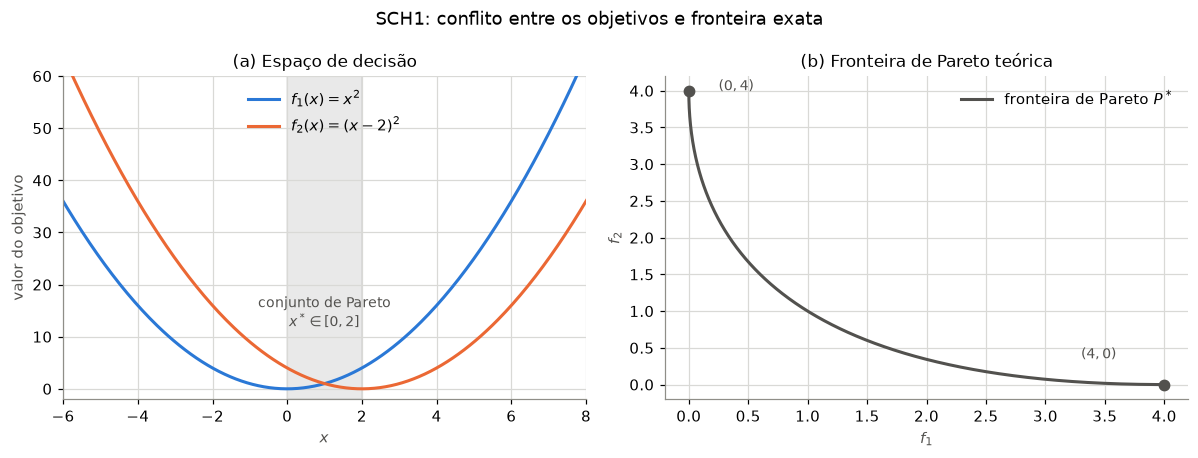

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) espaço de decisão
x_grid = np.linspace(-10, 10, 400)
ax = axes[0]
ax.plot(x_grid, x_grid ** 2, color=C_N2, label="$f_1(x)=x^2$")
ax.plot(x_grid, (x_grid - 2) ** 2, color=C_N3, label="$f_2(x)=(x-2)^2$")
ax.axvspan(0, 2, color=C_TRUE, alpha=0.12)
ax.annotate("conjunto de Pareto\n$x^* \\in [0,2]$", xy=(1, 12), ha="center",
            color=C_TRUE, fontsize=9)
ax.set_xlim(-6, 8)
ax.set_ylim(-2, 60)
ax.set_xlabel("$x$")
ax.set_ylabel("valor do objetivo")
ax.set_title("(a) Espaço de decisão")
ax.legend(loc="upper center")

# (b) espaço de objetivos
ax = axes[1]
ax.plot(PF_TRUE[:, 0], PF_TRUE[:, 1], color=C_TRUE, label="fronteira de Pareto $P^*$")
ax.scatter([0, 4], [4, 0], color=C_TRUE, s=45, zorder=3)
ax.annotate("$(0,4)$", xy=(0, 4), xytext=(0.25, 4.0), color=C_TRUE, fontsize=9)
ax.annotate("$(4,0)$", xy=(4, 0), xytext=(3.3, 0.35), color=C_TRUE, fontsize=9)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$")
ax.set_title("(b) Fronteira de Pareto teórica")
ax.legend(loc="upper right")

fig.suptitle("SCH1: conflito entre os objetivos e fronteira exata", fontsize=12)
fig.tight_layout()
plt.show()


## 2. Configuração do experimento

Ambos os algoritmos recebem **exatamente a mesma configuração**: mesma população inicial, mesmo tamanho de população, mesmo número de gerações e os mesmos operadores de cruzamento e mutação. A única diferença é o mecanismo de seleção ambiental — *crowding distance* no NSGA-II e *nicho por pontos de referência* no NSGA-III.

Para $M=2$ objetivos, os pontos de referência do NSGA-III formam o simplexo unidimensional $\{(i/p,\,1-i/p)\}_{i=0}^{p}$, ou seja, $p+1$ pontos. Seguindo a recomendação de Deb & Jain (2014) de usar aproximadamente um ponto de referência por indivíduo, adotamos $p = N-1$, com $N$ o tamanho da população. O efeito desse parâmetro é investigado na seção 7.


In [26]:
POP_SIZE = 100          # tamanho da população
GENERATIONS = 50        # número de gerações
BOUNDS = [(-10.0, 10.0)]  # limites da única variável de decisão
DIVISIONS = POP_SIZE - 1  # p: gera p+1 = POP_SIZE pontos de referência (M = 2)
SEED = 42                # semente do experimento principal

# Ponto de referência do hipervolume: 10% além do nadir (4, 4) da fronteira teórica
REF_POINT = np.array([4.4, 4.4])


def initial_population(pop_size: int, bounds: list[tuple[float, float]], seed: int) -> list[np.ndarray]:
    """Gera uma população inicial uniforme e reprodutível."""
    rng = random.Random(seed)
    return [
        np.array([rng.uniform(b[0], b[1]) for b in bounds], dtype=float)
        for _ in range(pop_size)
    ]


INITIAL_POP = initial_population(POP_SIZE, BOUNDS, SEED)
print(f"população inicial: {len(INITIAL_POP)} indivíduos em [{BOUNDS[0][0]}, {BOUNDS[0][1]}]")


população inicial: 100 indivíduos em [-10.0, 10.0]


### Operadores genéticos

Usamos os operadores clássicos para variáveis reais empregados nos artigos originais do NSGA-II e do NSGA-III:

* **SBX** (*Simulated Binary Crossover*), com índice de distribuição $\eta_c$: simula o cruzamento binário de um ponto em variáveis contínuas, gerando filhos próximos aos pais (valores altos de $\eta_c$) ou mais dispersos (valores baixos);
* **mutação polinomial**, com índice de distribuição $\eta_m$ e probabilidade $1/n$ por variável ($n$ = número de variáveis).

Ambos respeitam os limites das variáveis. As assinaturas seguem o protocolo esperado pelos módulos: `crossover(p1, p2) -> (c1, c2)` e `mutation(ind, bounds) -> ind`.


In [27]:
ETA_C = 20.0        # índice de distribuição do SBX
ETA_M = 20.0        # índice de distribuição da mutação polinomial
P_CROSSOVER = 0.9   # probabilidade de cruzamento por variável
P_MUTATION = 1.0    # fator da probabilidade de mutação (P_MUTATION / n por variável)


def crossover(parent1: np.ndarray, parent2: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """SBX (Deb & Agrawal, 1995) com respeito aos limites de BOUNDS."""
    child1, child2 = parent1.copy(), parent2.copy()

    for i in range(len(parent1)):
        if random.random() >= P_CROSSOVER:
            continue

        x1, x2 = min(parent1[i], parent2[i]), max(parent1[i], parent2[i])
        if abs(x2 - x1) < 1e-14:
            continue

        low, high = BOUNDS[i]
        u = random.random()

        # filho próximo ao limite inferior
        beta = 1.0 + 2.0 * (x1 - low) / (x2 - x1)
        alpha = 2.0 - beta ** -(ETA_C + 1.0)
        beta_q = (u * alpha) ** (1.0 / (ETA_C + 1.0)) if u <= 1.0 / alpha \
            else (1.0 / (2.0 - u * alpha)) ** (1.0 / (ETA_C + 1.0))
        y1 = 0.5 * ((x1 + x2) - beta_q * (x2 - x1))

        # filho próximo ao limite superior
        beta = 1.0 + 2.0 * (high - x2) / (x2 - x1)
        alpha = 2.0 - beta ** -(ETA_C + 1.0)
        beta_q = (u * alpha) ** (1.0 / (ETA_C + 1.0)) if u <= 1.0 / alpha \
            else (1.0 / (2.0 - u * alpha)) ** (1.0 / (ETA_C + 1.0))
        y2 = 0.5 * ((x1 + x2) + beta_q * (x2 - x1))

        child1[i] = min(max(y1, low), high)
        child2[i] = min(max(y2, low), high)

    return child1, child2


def mutation(individual: np.ndarray, bounds: list[tuple[float, float]]) -> np.ndarray:
    """Mutação polinomial (Deb & Goyal, 1996)."""
    mutant = individual.copy()
    n = len(mutant)

    for i in range(n):
        if random.random() >= P_MUTATION / n:
            continue

        low, high = bounds[i]
        x = mutant[i]
        span = high - low
        delta1 = (x - low) / span
        delta2 = (high - x) / span
        u = random.random()

        if u < 0.5:
            delta_q = (2.0 * u + (1.0 - 2.0 * u) * (1.0 - delta1) ** (ETA_M + 1.0)) ** (1.0 / (ETA_M + 1.0)) - 1.0
        else:
            delta_q = 1.0 - (2.0 * (1.0 - u) + 2.0 * (u - 0.5) * (1.0 - delta2) ** (ETA_M + 1.0)) ** (1.0 / (ETA_M + 1.0))

        mutant[i] = min(max(x + delta_q * span, low), high)

    return mutant


## 3. Execução dos algoritmos

As funções abaixo encapsulam as chamadas aos módulos. Há um detalhe de implementação que precisa ser levado em conta para comparar os dois algoritmos de forma justa:

* `nsga3_func` calcula a fronteira retornada **depois** de executar todas as `generations` iterações do laço evolutivo;
* `nsga2_func` calcula a fronteira retornada **no início** da última iteração, ou seja, após `generations - 1` passos evolutivos.

Por isso, para obter a fronteira após exatamente $g$ gerações de evolução, chamamos `nsga2_func` com `generations = g + 1` e `nsga3_func` com `generations = g`. Como as duas implementações usam o módulo `random` global, fixamos a semente imediatamente antes de cada chamada: isso torna as execuções reprodutíveis e, além disso, garante que uma execução com $g$ gerações seja **prefixo** de uma execução com $g' > g$ gerações — propriedade que usamos na seção 5.


In [28]:
def run_nsga2(generations: int, initial_pop: list[np.ndarray], seed: int = SEED) -> np.ndarray:
    """Executa o NSGA-II por `generations` passos evolutivos."""
    random.seed(seed)
    front = nsga2_func(
        pop_size=POP_SIZE,
        generations=generations + 1,  # ver observação sobre o instante de coleta da fronteira
        bounds=BOUNDS,
        functions=OBJECTIVES,
        crossover=crossover,
        mutation=mutation,
        initial_pop=copy.deepcopy(initial_pop),
    )
    return np.array(front, dtype=float)


def run_nsga3(generations: int, initial_pop: list[np.ndarray], seed: int = SEED,
              divisions: int = DIVISIONS) -> np.ndarray:
    """Executa o NSGA-III por `generations` passos evolutivos."""
    random.seed(seed)
    front = nsga3_func(
        pop_size=POP_SIZE,
        generations=generations,
        bounds=BOUNDS,
        functions=OBJECTIVES,
        crossover=crossover,
        mutation=mutation,
        initial_pop=copy.deepcopy(initial_pop),
        divisions=divisions,
    )
    return np.array(front, dtype=float)


start = time.time()
front_nsga2 = run_nsga2(GENERATIONS, INITIAL_POP)
t_nsga2 = time.time() - start

start = time.time()
front_nsga3 = run_nsga3(GENERATIONS, INITIAL_POP)
t_nsga3 = time.time() - start

print(f"NSGA-II : {len(front_nsga2):3d} soluções não dominadas em {t_nsga2:.2f}s")
print(f"NSGA-III: {len(front_nsga3):3d} soluções não dominadas em {t_nsga3:.2f}s")


NSGA-II : 100 soluções não dominadas em 1.46s
NSGA-III: 100 soluções não dominadas em 1.48s


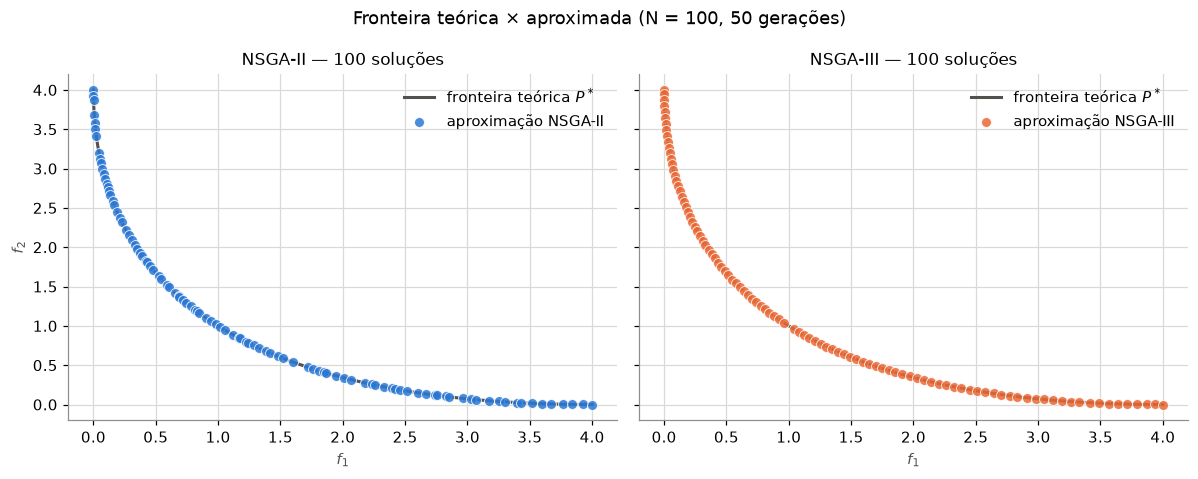

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)

for ax, front, color, name in (
    (axes[0], front_nsga2, C_N2, "NSGA-II"),
    (axes[1], front_nsga3, C_N3, "NSGA-III"),
):
    ax.plot(PF_TRUE[:, 0], PF_TRUE[:, 1], color=C_TRUE, label="fronteira teórica $P^*$")
    ax.scatter(front[:, 0], front[:, 1], s=42, color=color, alpha=0.85,
               edgecolor="white", linewidth=0.6, zorder=3, label=f"aproximação {name}")
    ax.set_xlabel("$f_1$")
    ax.set_title(f"{name} — {len(front)} soluções")
    ax.legend(loc="upper right")

axes[0].set_ylabel("$f_2$")
fig.suptitle(f"Fronteira teórica × aproximada (N = {POP_SIZE}, {GENERATIONS} gerações)", fontsize=12)
fig.tight_layout()
plt.show()


Visualmente as duas fronteiras aproximadas coincidem com a curva teórica: com uma única variável de decisão o SCH1 é fácil de **convergir**. A diferença entre os algoritmos aparece na **distribuição** dos pontos ao longo da curva, e é exatamente isso que as métricas a seguir quantificam.


## 4. Métricas de qualidade

Seja $A$ o conjunto de soluções não dominadas obtido pelo algoritmo e $P^*$ a fronteira de Pareto verdadeira (aqui amostrada com 1000 pontos). Denote por $d(u, S) = \min_{v \in S} \lVert u - v \rVert$ a distância euclidiana do ponto $u$ ao conjunto $S$.

**GD — Generational Distance** (convergência): quão perto de $P^*$ estão os pontos obtidos.

$$
GD(A,P^*) = \frac{1}{|A|}\left(\sum_{a \in A} d(a, P^*)^p\right)^{1/p}, \qquad p = 2.
$$

**IGD — Inverted Generational Distance** (convergência + cobertura): quão bem $A$ cobre $P^*$. Como a soma percorre $P^*$, regiões da fronteira **não cobertas** por $A$ penalizam a métrica — por isso o IGD é sensível também à diversidade.

$$
IGD(A,P^*) = \frac{1}{|P^*|}\sum_{p \in P^*} d(p, A).
$$

Em ambos, **menor é melhor**.

**HV — Hipervolume** (convergência + diversidade, sem exigir $P^*$): volume da região dominada por $A$ e limitada por um ponto de referência $r$ pior que todas as soluções.

$$
HV(A, r) = \text{Vol}\left(\bigcup_{a \in A} \prod_{i=1}^{M} [a_i, r_i]\right), \qquad \text{maior é melhor}.
$$

Usamos $r = 1{,}1 \cdot (4,4) = (4{,}4;\ 4{,}4)$, isto é, 10% além do nadir teórico. Em $M = 2$ o hipervolume é calculado exatamente por uma varredura: ordenando as soluções não dominadas por $f_1$ crescente (o que implica $f_2$ decrescente), a área é a soma dos retângulos disjuntos $(r_1 - f_1) \cdot (f_2^{\text{anterior}} - f_2)$.

> Pontos que não dominam $r$ (isto é, com alguma coordenada $\geq r_i$) precisam ser descartados antes do cálculo — caso contrário contribuiriam com áreas negativas. Isso é relevante nas primeiras gerações, quando a população ainda está longe da fronteira.


In [30]:
def min_distances(points: np.ndarray, reference_set: np.ndarray) -> np.ndarray:
    """Distância euclidiana mínima de cada ponto de `points` ao conjunto `reference_set`."""
    diff = points[:, None, :] - reference_set[None, :, :]
    return np.min(np.linalg.norm(diff, axis=2), axis=1)


def generational_distance(front: np.ndarray, true_front: np.ndarray, p: float = 2.0) -> float:
    """GD: convergência do conjunto obtido em relação à fronteira verdadeira."""
    d = min_distances(np.asarray(front, dtype=float), true_front)
    return float((np.sum(d ** p) ** (1.0 / p)) / len(d))


def inverted_generational_distance(front: np.ndarray, true_front: np.ndarray) -> float:
    """IGD: cobertura da fronteira verdadeira pelo conjunto obtido."""
    return float(np.mean(min_distances(true_front, np.asarray(front, dtype=float))))


def non_dominated(points: np.ndarray) -> np.ndarray:
    """Filtra o subconjunto não dominado (minimização)."""
    points = np.asarray(points, dtype=float)
    keep = [
        i for i, a in enumerate(points)
        if not np.any(np.all(points <= a, axis=1) & np.any(points < a, axis=1))
    ]
    return points[keep]


def hypervolume(front: np.ndarray, reference_point: np.ndarray = REF_POINT) -> float:
    """
    Hipervolume 2D por varredura, para minimização.

    :param front: array (n x 2) com os objetivos
    :param reference_point: ponto de referência (pior ponto)
    """
    points = np.asarray(front, dtype=float)
    reference_point = np.asarray(reference_point, dtype=float)

    # descarta pontos que não dominam o ponto de referência
    points = points[np.all(points < reference_point, axis=1)]
    if len(points) == 0:
        return 0.0

    points = non_dominated(points)
    points = points[np.argsort(points[:, 0])]  # f1 crescente => f2 decrescente

    area = 0.0
    previous_f2 = reference_point[1]
    for f1_value, f2_value in points:
        area += (reference_point[0] - f1_value) * (previous_f2 - f2_value)
        previous_f2 = f2_value
    return float(area)


In [31]:
# Verificação do hipervolume próprio contra a implementação da pymoo
from pymoo.indicators.hv import HV

hv_pymoo = HV(ref_point=REF_POINT)
for name, front in (("NSGA-II", front_nsga2), ("NSGA-III", front_nsga3), ("teórica", PF_TRUE)):
    print(f"{name:>9}: HV próprio = {hypervolume(front):.6f} | HV pymoo = {hv_pymoo(front):.6f}")


  NSGA-II: HV próprio = 16.630584 | HV pymoo = 16.630584
 NSGA-III: HV próprio = 16.637266 | HV pymoo = 16.637266
  teórica: HV próprio = 16.687989 | HV pymoo = 16.687989


In [32]:
HV_TRUE = hypervolume(PF_TRUE)

print(f"{'algoritmo':<10}{'GD':>12}{'IGD':>12}{'HV':>12}{'HV/HV*':>10}")
print("-" * 56)
for name, front in (("NSGA-II", front_nsga2), ("NSGA-III", front_nsga3)):
    gd_value = generational_distance(front, PF_TRUE)
    igd_value = inverted_generational_distance(front, PF_TRUE)
    hv_value = hypervolume(front)
    print(f"{name:<10}{gd_value:>12.3e}{igd_value:>12.5f}{hv_value:>12.5f}{hv_value / HV_TRUE:>10.4f}")
print(f"{'teórica':<10}{0.0:>12.3e}{inverted_generational_distance(PF_TRUE, PF_TRUE):>12.5f}"
      f"{HV_TRUE:>12.5f}{1.0:>10.4f}")


algoritmo           GD         IGD          HV    HV/HV*
--------------------------------------------------------
NSGA-II      1.817e-04     0.01969    16.63058    0.9966
NSGA-III     1.819e-04     0.01656    16.63727    0.9970
teórica      0.000e+00     0.00000    16.68799    1.0000


## 5. Evolução das métricas ao longo das gerações

Os módulos do repositório retornam apenas a fronteira **final**, sem histórico por geração. Para obter as curvas, reexecutamos cada algoritmo para $g = 0, 1, \dots, G$ gerações, sempre a partir da **mesma população inicial** e com a **mesma semente**. Como a sequência de números pseudoaleatórios consumida é idêntica, a execução com $g$ gerações é um prefixo exato da execução com $g+1$ — as curvas descrevem, portanto, uma única trajetória evolutiva, e não execuções independentes.

O custo é quadrático em $G$ ($\sum_{g} g$ gerações no total), o que é perfeitamente viável neste problema.


In [33]:
GEN_GRID = list(range(0, GENERATIONS + 1))

history: dict[str, dict[str, list[float]]] = {
    "NSGA-II": {"gd": [], "igd": [], "hv": []},
    "NSGA-III": {"gd": [], "igd": [], "hv": []},
}

start = time.time()
for g in GEN_GRID:
    for name, front in (("NSGA-II", run_nsga2(g, INITIAL_POP)),
                        ("NSGA-III", run_nsga3(g, INITIAL_POP))):
        history[name]["gd"].append(generational_distance(front, PF_TRUE))
        history[name]["igd"].append(inverted_generational_distance(front, PF_TRUE))
        history[name]["hv"].append(hypervolume(front))

print(f"{2 * len(GEN_GRID)} execuções concluídas em {time.time() - start:.1f}s")
print(f"{'ger.':>5}{'GD (II)':>12}{'GD (III)':>12}{'IGD (II)':>12}{'IGD (III)':>12}{'HV (II)':>10}{'HV (III)':>10}")
for g in (0, 1, 5, 10, 25, GENERATIONS):
    i = GEN_GRID.index(g)
    print(f"{g:>5}{history['NSGA-II']['gd'][i]:>12.3e}{history['NSGA-III']['gd'][i]:>12.3e}"
          f"{history['NSGA-II']['igd'][i]:>12.4f}{history['NSGA-III']['igd'][i]:>12.4f}"
          f"{history['NSGA-II']['hv'][i]:>10.4f}{history['NSGA-III']['hv'][i]:>10.4f}")


102 execuções concluídas em 75.7s
 ger.     GD (II)    GD (III)    IGD (II)   IGD (III)   HV (II)  HV (III)
    0   2.531e-02   2.531e-02      0.1963      0.1963   16.0010   16.0010
    1   1.688e-02   2.658e-04      0.1640      0.0989   16.1346   16.3681
    5   1.206e-03   1.820e-04      0.0224      0.0247   16.6180   16.6225
   10   1.856e-04   1.794e-04      0.0218      0.0197   16.6167   16.6292
   25   1.834e-04   1.756e-04      0.0207      0.0169   16.6260   16.6366
   50   1.817e-04   1.819e-04      0.0197      0.0166   16.6306   16.6373


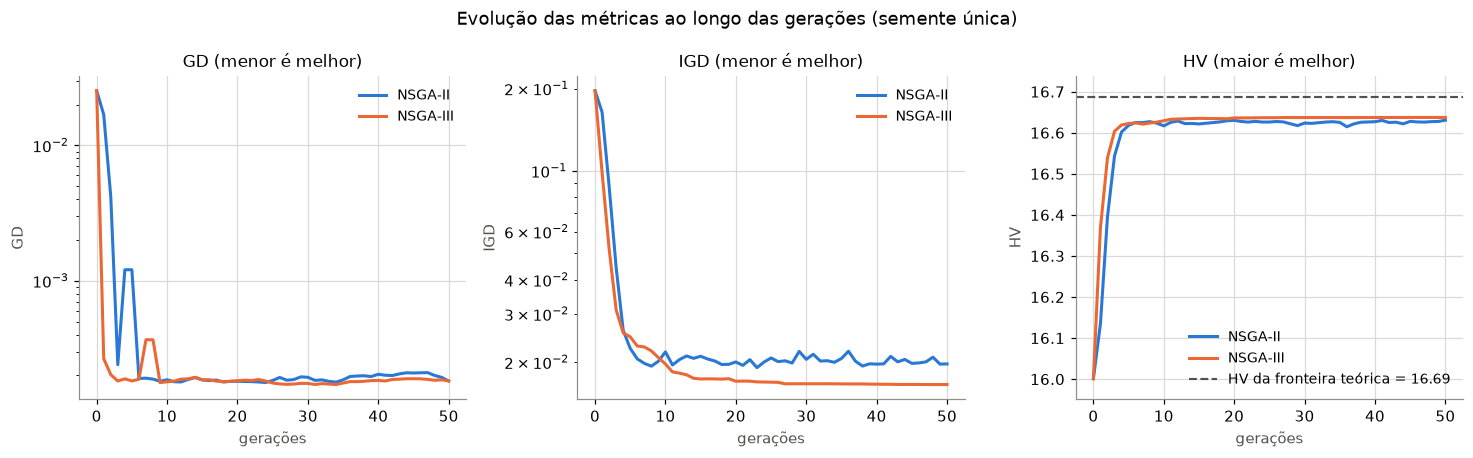

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

panels = [
    ("gd", "GD (menor é melhor)", "GD", True),
    ("igd", "IGD (menor é melhor)", "IGD", True),
    ("hv", "HV (maior é melhor)", "HV", False),
]

for ax, (key, title, ylabel, log_scale) in zip(axes, panels):
    for name, color in (("NSGA-II", C_N2), ("NSGA-III", C_N3)):
        ax.plot(GEN_GRID, history[name][key], color=color, label=name)
    if log_scale:
        ax.set_yscale("log")
    if key == "hv":
        ax.axhline(HV_TRUE, color=C_TRUE, linestyle="--", linewidth=1.4,
                   label=f"HV da fronteira teórica = {HV_TRUE:.2f}")
        # eixo ampliado: toda a variação relevante está próxima do valor teórico
        hv_min = min(min(history[n]["hv"]) for n in history)
        ax.set_ylim(hv_min - 0.05, HV_TRUE + 0.05)
    ax.set_xlabel("gerações")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9)

fig.suptitle("Evolução das métricas ao longo das gerações (semente única)", fontsize=12)
fig.tight_layout()
plt.show()


**Leitura dos gráficos**

* **GD** cai várias ordens de grandeza já nas primeiras gerações e depois estabiliza: os pontos passam a estar praticamente *sobre* a curva teórica. A partir daí, o GD deixa de discriminar os algoritmos — é uma métrica de convergência pura, indiferente a como os pontos se distribuem (um algoritmo que concentrasse todas as soluções em um único ponto da fronteira teria GD ótimo).
* **IGD** continua caindo depois que o GD satura, porque ainda há regiões da fronteira mal cobertas. É a curva que revela a diferença de **diversidade** entre os dois mecanismos de seleção.
* **HV** sobe rapidamente e satura próximo do hipervolume da fronteira teórica (linha tracejada). A distância residual até essa linha é a perda por representar uma curva contínua com um número finito de pontos.


## 6. Robustez: repetição com várias sementes

Uma única execução pode favorecer um algoritmo por acaso. Repetimos o experimento com sementes diferentes — cada semente gera uma população inicial distinta e uma trajetória distinta — e resumimos as métricas finais por média e desvio padrão.


In [35]:
SEEDS = [1, 2, 3, 5, 7, 11, 13, 17, 19, 23]

results: dict[str, dict[str, list[float]]] = {
    "NSGA-II": {"gd": [], "igd": [], "hv": []},
    "NSGA-III": {"gd": [], "igd": [], "hv": []},
}

start = time.time()
for seed in SEEDS:
    init_pop = initial_population(POP_SIZE, BOUNDS, seed)
    for name, front in (("NSGA-II", run_nsga2(GENERATIONS, init_pop, seed=seed)),
                        ("NSGA-III", run_nsga3(GENERATIONS, init_pop, seed=seed))):
        results[name]["gd"].append(generational_distance(front, PF_TRUE))
        results[name]["igd"].append(inverted_generational_distance(front, PF_TRUE))
        results[name]["hv"].append(hypervolume(front))

print(f"{len(SEEDS)} sementes × 2 algoritmos em {time.time() - start:.1f}s\n")
print(f"{'algoritmo':<10}{'GD (méd ± dp)':>26}{'IGD (méd ± dp)':>26}{'HV (méd ± dp)':>26}")
print("-" * 88)
for name in ("NSGA-II", "NSGA-III"):
    r = results[name]
    print(f"{name:<10}"
          f"{np.mean(r['gd']):>15.3e} ± {np.std(r['gd']):<8.1e}"
          f"{np.mean(r['igd']):>15.5f} ± {np.std(r['igd']):<8.5f}"
          f"{np.mean(r['hv']):>15.5f} ± {np.std(r['hv']):<8.5f}")
print(f"\nHV da fronteira teórica: {HV_TRUE:.5f}")


10 sementes × 2 algoritmos em 29.5s

algoritmo              GD (méd ± dp)            IGD (méd ± dp)             HV (méd ± dp)
----------------------------------------------------------------------------------------
NSGA-II         1.930e-04 ± 1.5e-05         0.02062 ± 0.00050        16.62331 ± 0.00296 
NSGA-III        1.944e-04 ± 1.4e-05         0.01680 ± 0.00041        16.63646 ± 0.00164 

HV da fronteira teórica: 16.68799


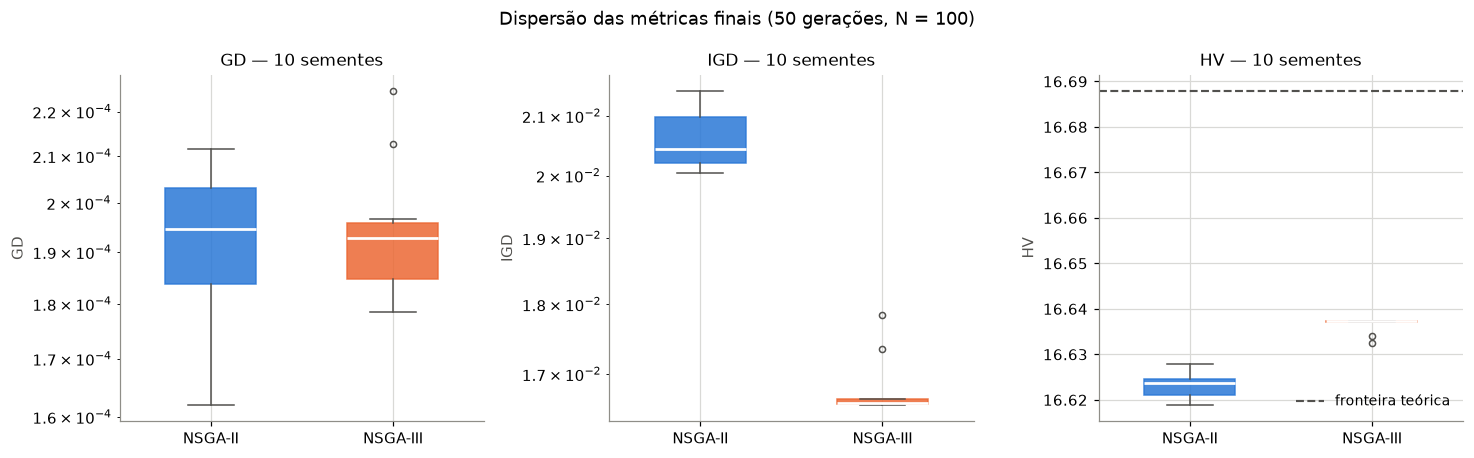

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

for ax, (key, title) in zip(axes, [("gd", "GD"), ("igd", "IGD"), ("hv", "HV")]):
    data = [results["NSGA-II"][key], results["NSGA-III"][key]]
    box = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=["NSGA-II", "NSGA-III"],
                     medianprops={"color": "white", "linewidth": 1.8},
                     flierprops={"marker": "o", "markersize": 4, "markerfacecolor": "none",
                                 "markeredgecolor": C_TRUE})
    for patch, color in zip(box["boxes"], (C_N2, C_N3)):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor(color)
    for element in ("whiskers", "caps"):
        for item in box[element]:
            item.set_color(C_TRUE)
    if key in ("gd", "igd"):
        ax.set_yscale("log")
    if key == "hv":
        ax.axhline(HV_TRUE, color=C_TRUE, linestyle="--", linewidth=1.4, label="fronteira teórica")
        ax.legend(loc="lower right", fontsize=9)
    ax.set_ylabel(key.upper())
    ax.set_title(f"{title} — {len(SEEDS)} sementes")

fig.suptitle(f"Dispersão das métricas finais ({GENERATIONS} gerações, N = {POP_SIZE})", fontsize=12)
fig.tight_layout()
plt.show()


## 7. Efeito do número de pontos de referência no NSGA-III

No NSGA-III a diversidade é induzida pelos pontos de referência: cada solução é associada ao ponto de referência mais próximo (em direção) e a seleção prioriza os nichos menos povoados. Com $M=2$ objetivos e $p$ divisões, há $p+1$ pontos de referência. Se $p+1 \ll N$, vários indivíduos disputam o mesmo nicho e a fronteira final fica com pontos agrupados; à medida que $p+1$ se aproxima de $N$, a distribuição fica mais uniforme.


In [37]:
DIVISIONS_GRID = [4, 9, 19, 39, 59, 79, 99]

igd_by_divisions = []
hv_by_divisions = []
fronts_by_divisions = {}

for divisions in DIVISIONS_GRID:
    front = run_nsga3(GENERATIONS, INITIAL_POP, divisions=divisions)
    fronts_by_divisions[divisions] = front
    igd_by_divisions.append(inverted_generational_distance(front, PF_TRUE))
    hv_by_divisions.append(hypervolume(front))

print(f"{'p':>4}{'pontos de ref.':>16}{'IGD':>12}{'HV':>12}")
print("-" * 44)
for divisions, igd_value, hv_value in zip(DIVISIONS_GRID, igd_by_divisions, hv_by_divisions):
    print(f"{divisions:>4}{divisions + 1:>16}{igd_value:>12.5f}{hv_value:>12.5f}")
print(f"\nreferência NSGA-II (mesma semente): IGD = "
      f"{inverted_generational_distance(front_nsga2, PF_TRUE):.5f}, "
      f"HV = {hypervolume(front_nsga2):.5f}")


   p  pontos de ref.         IGD          HV
--------------------------------------------
   4               5     0.41407    14.59896
   9              10     0.18522    15.87658
  19              20     0.08446    16.36809
  39              40     0.04098    16.54794
  59              60     0.02600    16.60530
  79              80     0.02029    16.62374
  99             100     0.01656    16.63727

referência NSGA-II (mesma semente): IGD = 0.01969, HV = 16.63058


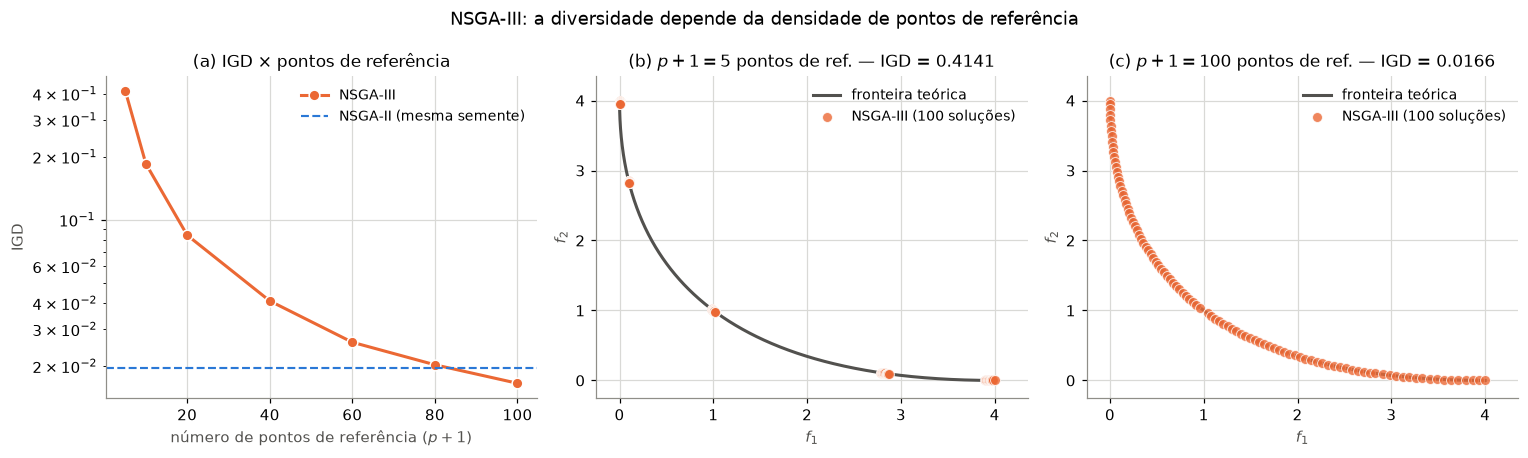

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# (a) IGD em função do número de pontos de referência
ax = axes[0]
n_refs = [d + 1 for d in DIVISIONS_GRID]
ax.plot(n_refs, igd_by_divisions, color=C_N3, marker="o", markersize=7,
        markeredgecolor="white", label="NSGA-III")
ax.axhline(inverted_generational_distance(front_nsga2, PF_TRUE), color=C_N2,
           linestyle="--", linewidth=1.4, label="NSGA-II (mesma semente)")
ax.set_yscale("log")
ax.set_xlabel("número de pontos de referência ($p+1$)")
ax.set_ylabel("IGD")
ax.set_title("(a) IGD × pontos de referência")
ax.legend(loc="upper right", fontsize=9)

# (b) e (c) fronteiras obtidas nos dois extremos de p
for ax, divisions, panel in ((axes[1], DIVISIONS_GRID[0], "(b)"), (axes[2], DIVISIONS_GRID[-1], "(c)")):
    front = fronts_by_divisions[divisions]
    igd_value = inverted_generational_distance(front, PF_TRUE)
    ax.plot(PF_TRUE[:, 0], PF_TRUE[:, 1], color=C_TRUE, label="fronteira teórica")
    ax.scatter(front[:, 0], front[:, 1], s=42, color=C_N3, alpha=0.8,
               edgecolor="white", linewidth=0.6, zorder=3,
               label=f"NSGA-III ({len(front)} soluções)")
    ax.set_xlim(-0.25, 4.35)
    ax.set_ylim(-0.25, 4.35)
    ax.set_xlabel("$f_1$")
    ax.set_ylabel("$f_2$")
    ax.set_title(f"{panel} $p+1 = {divisions + 1}$ pontos de ref. — IGD = {igd_value:.4f}")
    ax.legend(loc="upper right", fontsize=9)

fig.suptitle("NSGA-III: a diversidade depende da densidade de pontos de referência", fontsize=12)
fig.tight_layout()
plt.show()


## 8. Conclusões

* O **SCH1** tem fronteira de Pareto analítica ($\{(f_1,(2-\sqrt{f_1})^2): f_1 \in [0,4]\}$, correspondente a $x^*\in[0,2]$), o que permite calcular GD e IGD contra a fronteira exata em vez de um conjunto de referência estimado.
* Ambas as implementações do repositório **convergem** para a fronteira teórica: o GD cai várias ordens de grandeza em poucas gerações e satura, deixando de distinguir os algoritmos.
* A diferença relevante está na **distribuição** das soluções, capturada pelo IGD e pelo HV. Com $p+1 = N$ pontos de referência, o NSGA-III ficou consistentemente melhor que o NSGA-II nas 10 sementes (IGD $\approx 0{,}0168$ contra $\approx 0{,}0206$), com dispersão bem menor entre execuções: os pontos de referência impõem uma malha fixa e uniforme, enquanto a *crowding distance* do NSGA-II produz um espaçamento que flutua de execução para execução.
* Esse ganho, porém, **depende inteiramente do parâmetro $p$**: reduzir os pontos de referência de 100 para 5 piora o IGD em mais de uma ordem de grandeza (seção 7), pois as soluções se agrupam em poucos nichos. O NSGA-II não tem parâmetro equivalente a ajustar.
* Vale lembrar o propósito de cada algoritmo: o NSGA-III foi projetado para problemas **muitos-objetivos** ($M \geq 4$), em que a *crowding distance* perde poder discriminante. Em $M=2$, como aqui, a vantagem observada é pequena em termos absolutos — ambos ficam a menos de 0,5% do hipervolume da fronteira teórica.
* Metodologicamente, vale registrar que GD isolado é uma métrica fraca — um conjunto degenerado concentrado em um único ponto da fronteira teria GD ótimo. IGD e HV, que combinam convergência e cobertura, são as métricas que devem guiar a comparação.

**Notebooks relacionados**

* [Métricas GD e IGD](./generational_distance.ipynb)
* [Hipervolume](./hypervolume.ipynb)
* [Distribuição por nichos](./niche_distribution.ipynb)
* [Implementação NSGA-II](../basic/nsga-2.ipynb) e [Implementação NSGA-III](../basic/nsga-3.ipynb)
